In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import sklearn.metrics as sm 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.cluster.hierarchy import dendrogram
from scipy.spatial import distance


In [5]:
# Loading the data 
all4_gtsB_gtsD_clusters = pd.read_csv('quantitative_variable_contribution_percluster_4-fold_08_consensusf_gtsB_gtsD.csv')
print(all4_gtsB_gtsD_clusters.shape)
print(all4_gtsB_gtsD_clusters.head())
print(all4_gtsB_gtsD_clusters.isnull().sum())
print(all4_gtsB_gtsD_clusters.shape)
print(all4_gtsB_gtsD_clusters.info())

(120, 10)
   gene  cluster                            variables    v.test  \
0  gtsB        1  T-ending codon relative probability -8.426704   
1  gtsB        1  C-ending codon relative probability -7.474167   
2  gtsB        1                  C-ending codon RSCU -6.916618   
3  gtsB        1                  T-ending codon RSCU -5.403268   
4  gtsB        1                          Transitions -4.729488   

   mean_in_cluster  overall_mean  sd_in_cluster  overall_sd       p.value  \
0         0.128804      0.245095       0.088853    0.151803  0.000000e+00   
1         0.282716      0.355577       0.091121    0.107233  7.770000e-14   
2         1.297364      1.801160       0.441990    0.801224  4.630000e-12   
3         0.309818      0.424210       0.085506    0.232879  6.540000e-08   
4       109.481256    169.803745      62.298761  140.300055  2.250000e-06   

   n_in_cluster  
0            55  
1            55  
2            55  
3            55  
4            55  
gene            

In [6]:
##filtering by gene, first gtsB

filtered_gtsBclusters4all = all4_gtsB_gtsD_clusters[all4_gtsB_gtsD_clusters['gene'] == 'gtsB']  
print(filtered_gtsBclusters4all.shape)

(45, 10)


In [7]:
filtered_gtsBclusters4allf = filtered_gtsBclusters4all.query("variables in ['A-ending codon relative probability', 'C-ending codon relative probability', 	'G-ending codon relative probability', 	'T-ending codon relative probability', 	'Substitution rate', 	'Transitions', 	'Transversions' ]")

In [8]:
##n sizes per cluster gtsB k
n_number= [55,24,21]


In [9]:
# Color palette with fixed colors for each variable
#fixed_colors = {'A-ended codon frequency':'dodgerblue','A-ended codon mean W':'#E31A1C','A-ended codon RSCU':'green','C-ended codon frequency':'#6A3D9A','C-ended codon mean W':'#FF7F00','C-ended codon RSCU':'deeppink','G_codon_mean_freq':'gold','G-ended codon frequency':'skyblue','G-ended codon mean W':'#FB9A99','G-ended codon RSCU':'blue','T-ended codon frequency':'#CAB2D6','T-ended codon mean W':'#FDBF6F','T-ended codon RSCU':'black','Total mean substitutions':'khaki','Transitions':'maroon','Transversions':'orchid','Z-score':'gray'
#               }



fixed_colors ={'A-ending codon relative probability':'dodgerblue','C-ending codon relative probability':'#6A3D9A','G-ending codon relative probability':'skyblue','T-ending codon relative probability':'#CAB2D6','Substitution rate':'blue','Transitions':'maroon','Transversions':'orchid'}



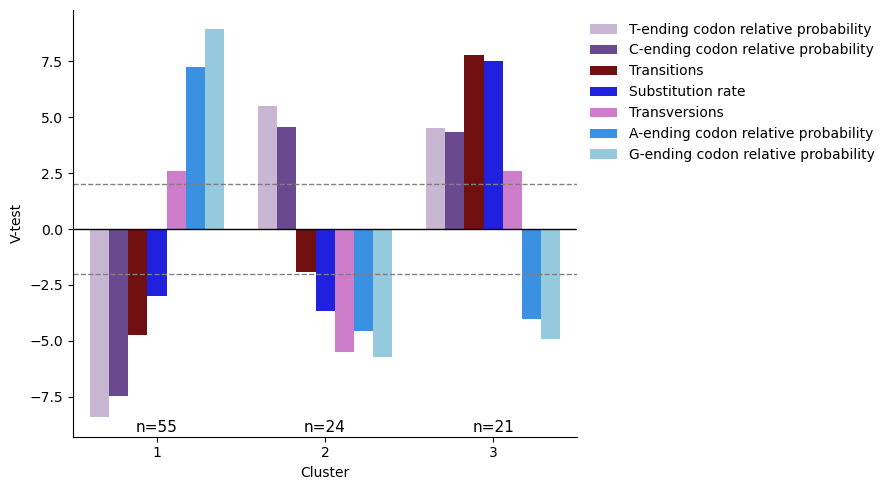

In [10]:
fig = plt.figure(figsize=(9, 5))  

# Create the bar plot
sns.barplot(data=filtered_gtsBclusters4allf, x='cluster', y='v.test', hue='variables', palette=fixed_colors, linewidth=10)

# Add n number under x-axis labels
for i, v in enumerate(n_number):
    plt.text(i, -9.1, f'n={v}', ha='center', fontsize=11, color='black')
        
        
# labels and title
plt.xlabel('Cluster')
plt.ylabel('V-test')
plt.title('')



# Set legend position to the right without overlapping
plt.legend(frameon=False,loc='upper left', bbox_to_anchor=(1, 1), title='')

# Add horizontal lines at Y=2 and Y=-2
plt.axhline(2, color='gray', linestyle='--', linewidth=1)
plt.axhline(-2, color='gray', linestyle='--', linewidth=1)
# Add a black line at y=0
plt.axhline(0, color='black', linewidth=1)

# Remove borders around the graph
sns.despine()

# Remove legend border
plt.legend(frameon=False, bbox_to_anchor=(1, 1), fontsize=10)

plt.tight_layout()  # Adjust layout

# Saving to PNG
plt.savefig('barplot_gtsB_4_fold_3_consenclustersfinal_2PCA_2f_fs_08.png', dpi=1000)
plt.show()  
    

In [11]:
##filtering by gene, then gtsD

filtered_gtsDclusters4all = all4_gtsB_gtsD_clusters[all4_gtsB_gtsD_clusters['gene'] == 'gtsD']  
print(filtered_gtsDclusters4all.shape)

(75, 10)


In [12]:
filtered_gtsDclusters4allf = filtered_gtsDclusters4all.query("variables in ['A-ending codon relative probability', 'C-ending codon relative probability', 	'G-ending codon relative probability', 	'T-ending codon relative probability', 	'Substitution rate', 	'Transitions', 	'Transversions' ]")

In [13]:
##n sizes per cluster gtsD
n_number= [17,33,34,19,29]


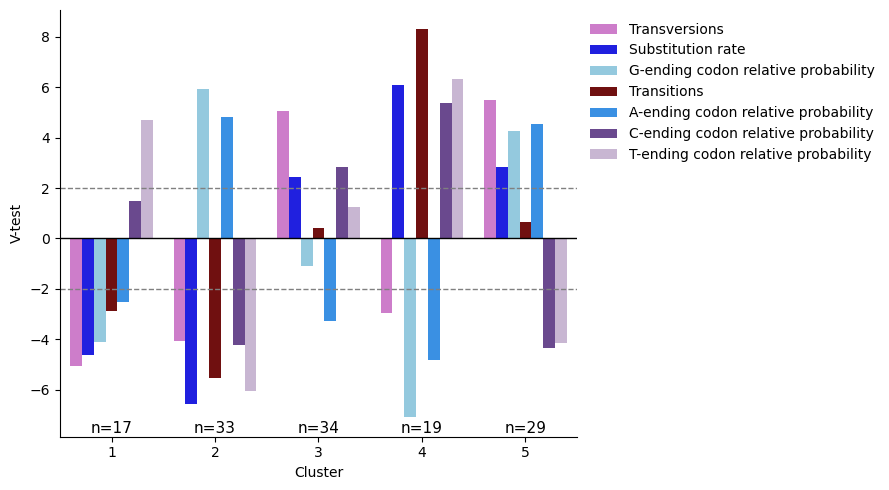

In [14]:
fig = plt.figure(figsize=(9, 5))  

# Create the bar plot
sns.barplot(data=filtered_gtsDclusters4allf, x='cluster', y='v.test', hue='variables', palette=fixed_colors, linewidth=10)

#labels and title
plt.xlabel('Cluster')
plt.ylabel('V-test')
plt.title('')

# Add n number under x-axis labels
for i, v in enumerate(n_number):
    plt.text(i, -7.7, f'n={v}', ha='center', fontsize=11, color='black')

#legend position to the right without overlapping
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Variables', ncol=1)


# Adding a black line at y=0
plt.axhline(0, color='black', linewidth=1)

# Add horizontal lines at Y=2 and Y=-2
plt.axhline(2, color='gray', linestyle='--', linewidth=1)
plt.axhline(-2, color='gray', linestyle='--', linewidth=1)

# Remove borders around the graph
sns.despine()

# Remove legend border
plt.legend(frameon=False, bbox_to_anchor=(1, 1), fontsize=10)

plt.tight_layout()  # Adjust layout

# Saving to PNG
plt.savefig('barplot_gtsD_4fold_5_consens_clusters_2pcaf_2f_f_08.png', dpi=1000)
plt.show()  
    